# Showcase — Gaza, satellite change detection (Khan Younis, 2023 → 2024)

Before/after satellite imagery is a standard humanitarian remote-sensing tool for **damage assessment** (organisations such as UNOSAT use it routinely). This notebook uses earthlens to pull a **two-year Sentinel-2 time series** over **Khan Younis** in southern Gaza, animates the progression, and adds an **NDVI (vegetation index) analysis** that quantifies the loss of green cover between May 2023 and May 2024. The imagery is presented factually; no interpretation beyond what the pixels show.

> Runs real Earth Engine requests; degrades gracefully without GEE credentials.

In [1]:
import os, tempfile, base64
from datetime import date, timedelta
import numpy as np, matplotlib.pyplot as plt
import matplotlib.animation as manim
from loguru import logger
from IPython.display import HTML
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable("earthlens")  # quieten download logs for a clean notebook
logger.disable("pyramids")   # silence pyramids/GDAL info+warning chatter

# Earth Engine needs a registered service account + its JSON key. Set
# GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY in your environment (see the GEE
# Authentication docs); the placeholders keep this notebook importable.
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")
AOI = None  # set per notebook: [lon_min, lat_min, lon_max, lat_max]


def scene(day, bands, scale, reducer="median"):
    """Download one single-day GEE composite; return its GeoTIFF path or None."""
    nxt = (date.fromisoformat(day) + timedelta(days=1)).isoformat()
    out = tempfile.mkdtemp(prefix="scene_")
    el = EarthLens(
        data_source="gee", start=day, end=nxt, temporal_resolution="raw",
        variables={COLLECTION: list(bands)},
        lat_lim=[AOI[1], AOI[3]], lon_lim=[AOI[0], AOI[2]],
        path=out, scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
    )
    try:
        paths = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001 - notebook stays runnable without creds
        print("download skipped (needs GEE credentials):", exc)
        return None
    return str(paths[0]) if paths else None


def read(path):
    """Read a GeoTIFF into a float32 array (bands, rows, cols) or (rows, cols)."""
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")


def stretch(band, pct=(2, 98)):
    lo, hi = np.nanpercentile(band, pct[0]), np.nanpercentile(band, pct[1])
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)


def true_colour(arr):
    """RGB (rows, cols, 3) from a B4/B3/B2 stack with a per-band 2-98% stretch."""
    return np.dstack([stretch(arr[i]) for i in range(3)])


def gif_html(frames, titles, suptitle, cmap=None, figsize=(6, 6), fps=1.2):
    """Render a list of image arrays to a looping GIF embedded as <img> HTML."""
    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(0, 0, 1, 0.93)

    def update(i):
        ax.clear()
        ax.imshow(frames[i], cmap=cmap)
        ax.set_title(f"{suptitle}\n{titles[i]}", fontsize=11)
        ax.axis("off")

    anim = manim.FuncAnimation(fig, update, frames=len(frames), interval=int(1000 / fps))
    path = os.path.join(tempfile.mkdtemp(), "anim.gif")
    anim.save(path, writer=manim.PillowWriter(fps=fps))
    plt.close(fig)
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    return HTML(f'<img src="data:image/gif;base64,{b64}" alt="{suptitle}" style="max-width:560px"/>')

COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
AOI = [34.28, 31.32, 34.33, 31.37]  # Khan Younis, southern Gaza

## A two-year Sentinel-2 time series

Clear-sky true-colour scenes roughly every few months across 2023–2024. May is cloud-free over the eastern Mediterranean, so each date gives a clean single-scene image.

In [2]:
DATES = ["2023-01-15", "2023-05-15", "2023-09-12", "2023-12-11", "2024-03-10", "2024-05-09", "2024-09-11"]
frames, labels = [], []
for d in DATES:
    p = scene(d, ["B4", "B3", "B2"], scale=10)
    if p:
        frames.append(true_colour(read(p))); labels.append(d)
print(f"{len(frames)} scenes fetched:", labels)

7 scenes fetched: ['2023-01-15', '2023-05-15', '2023-09-12', '2023-12-11', '2024-03-10', '2024-05-09', '2024-09-11']


## Animated progression (2023 → 2024)


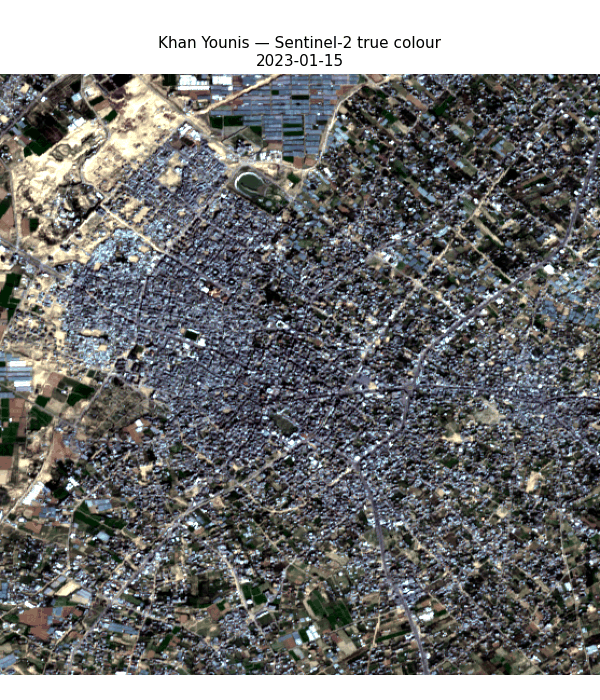

In [3]:
if frames:
    display(gif_html(frames, labels, "Khan Younis — Sentinel-2 true colour", figsize=(6, 7), fps=1.2))
else:
    print("no scenes — set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")

## NDVI analysis — quantifying vegetation loss

NDVI = (NIR − Red) / (NIR + Red) measures green vegetation (high = lush, near-zero = bare ground / rubble). We pull the near-infrared (`B8`) and red (`B4`) bands for the same May window in 2023 and 2024 and compare.

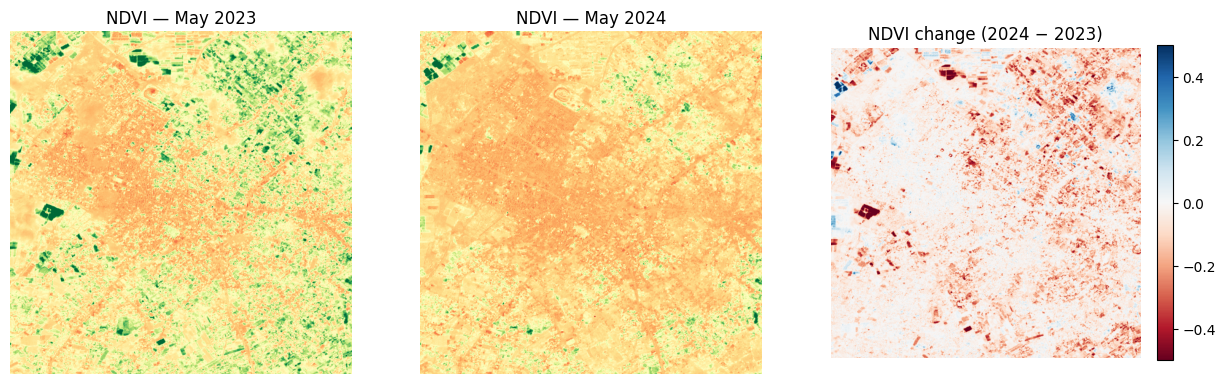

mean NDVI  2023: 0.181   2024: 0.119   change: -0.062
vegetated fraction (NDVI>0.3)  2023: 13.4%   2024: 2.7%


In [4]:
def ndvi(day):
    p = scene(day, ["B8", "B4"], scale=10)
    if not p:
        return None
    a = read(p); nir, red = a[0], a[1]
    return (nir - red) / (nir + red + 1e-6)

nd_before, nd_after = ndvi("2023-05-15"), ndvi("2024-05-09")
if nd_before is not None and nd_after is not None:
    diff = nd_after - nd_before
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(nd_before, cmap="RdYlGn", vmin=-0.2, vmax=0.6); ax[0].set_title("NDVI — May 2023")
    ax[1].imshow(nd_after, cmap="RdYlGn", vmin=-0.2, vmax=0.6); ax[1].set_title("NDVI — May 2024")
    im = ax[2].imshow(diff, cmap="RdBu", vmin=-0.5, vmax=0.5); ax[2].set_title("NDVI change (2024 − 2023)")
    for a in ax: a.axis("off")
    fig.colorbar(im, ax=ax[2], fraction=0.046)
    plt.show()
    mb, ma = float(np.nanmean(nd_before)), float(np.nanmean(nd_after))
    veg = lambda x: float(np.mean(x > 0.3))
    print(f"mean NDVI  2023: {mb:.3f}   2024: {ma:.3f}   change: {ma - mb:+.3f}")
    print(f"vegetated fraction (NDVI>0.3)  2023: {veg(nd_before):.1%}   2024: {veg(nd_after):.1%}")
else:
    print("no NDVI scenes — set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")